<a href="https://colab.research.google.com/github/Arnav-11/JAR/blob/main/JAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 150


In [ ]:
orders = pd.read_excel("List_of_Orders.xlsx")
details = pd.read_excel("Order_Details.xlsx")
target = pd.read_excel("Sales_target.xlsx")

print("Orders:", orders.shape, list(orders.columns))
print("Details:", details.shape, list(details.columns))
print("Target:", target.shape, list(target.columns))

Orders: (500, 5) ['Order ID', 'Order Date', 'CustomerName', 'State', 'City']
Details: (1500, 6) ['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category']
Target: (36, 3) ['Month of Order Date', 'Category', 'Target']


# PART 1: SALES & PROFITABILITY ANALYSIS

In [ ]:
merged = pd.merge(orders, details, on="Order ID", how="inner")
print("\nMerged shape:", merged.shape)

cat_summary = merged.groupby("Category").agg(
    Total_Sales=("Amount", "sum"),
    Total_Profit=("Profit", "sum"),
    Avg_Profit_per_Order=("Profit", "mean"),
    Order_Count=("Order ID", "count"),
).reset_index()
cat_summary["Profit_Margin_%"] = (cat_summary["Total_Profit"] / cat_summary["Total_Sales"]) * 100
cat_summary = cat_summary.sort_values("Total_Sales", ascending=False)

print("\n=== PART 1: Category-wise Sales & Profitability ===")
print(cat_summary.to_string(index=False))





Merged shape: (1500, 10)

=== PART 1: Category-wise Sales & Profitability ===
   Category  Total_Sales  Total_Profit  Avg_Profit_per_Order  Order_Count  Profit_Margin_%
Electronics       165267         10494             34.071429          308         6.349725
   Clothing       139054         11163             11.762908          949         8.027817
  Furniture       127181          2298              9.456790          243         1.806874


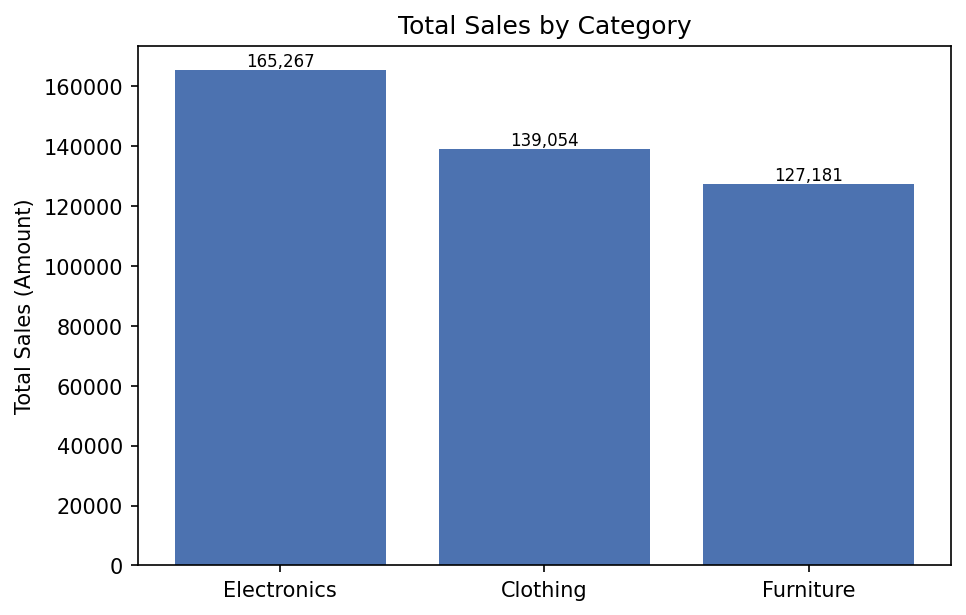

In [ ]:
# Chart: Total sales by category
fig, ax1 = plt.subplots(figsize=(7, 4.5))
bars = ax1.bar(cat_summary["Category"], cat_summary["Total_Sales"], color="#4C72B0")
ax1.set_ylabel("Total Sales (Amount)")
ax1.set_title("Total Sales by Category")
for b in bars:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():,.0f}",
              ha="center", va="bottom", fontsize=8)



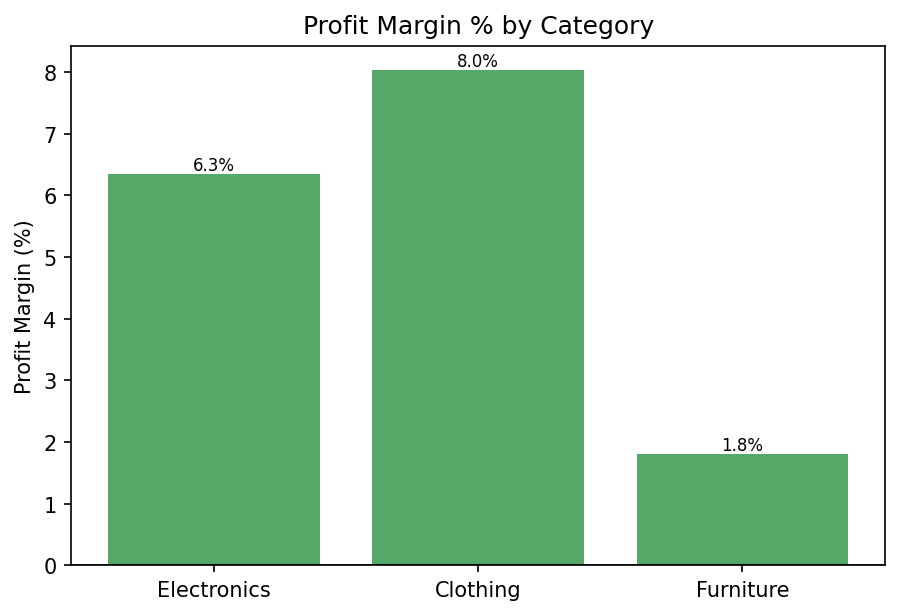

In [ ]:
# Chart: Profit margin % by category
fig, ax2 = plt.subplots(figsize=(7, 4.5))
colors = ["#55A868" if v >= 0 else "#C44E52" for v in cat_summary["Profit_Margin_%"]]
bars2 = ax2.bar(cat_summary["Category"], cat_summary["Profit_Margin_%"], color=colors)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Profit Margin (%)")
ax2.set_title("Profit Margin % by Category")
for b in bars2:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.1f}%",
              ha="center", va="bottom" if b.get_height() >= 0 else "top", fontsize=8)


# PART 2: TARGET ACHIEVEMENT ANALYSIS (Furniture)


=== PART 2: Furniture Target Month-over-Month Change ===
Month of Order Date  Category  Target  MoM_Change_%
         2026-01-19 Furniture   11500           NaN
         2026-02-19 Furniture   11600      0.869565
         2026-03-19 Furniture   11800      1.724138
         2026-04-18 Furniture   10400    -11.864407
         2026-05-18 Furniture   10500      0.961538
         2026-06-18 Furniture   10600      0.952381
         2026-07-18 Furniture   10800      1.886792
         2026-08-18 Furniture   10900      0.925926
         2026-09-18 Furniture   11000      0.917431
         2026-10-18 Furniture   11100      0.909091
         2026-11-18 Furniture   11300      1.801802
         2026-12-18 Furniture   11400      0.884956


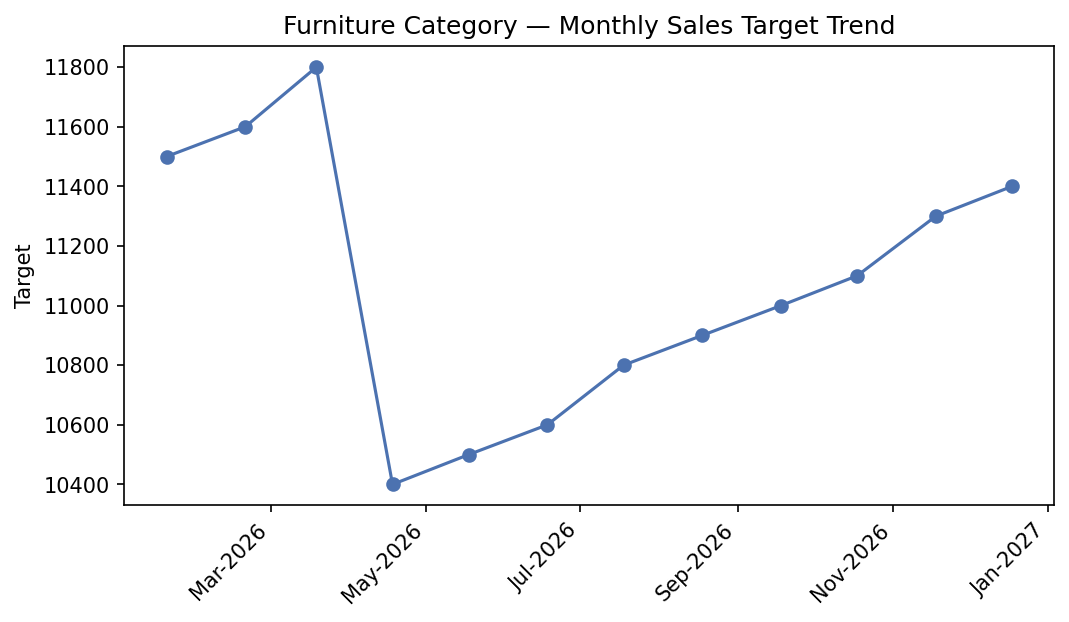

In [ ]:
furniture_target = target[target["Category"] == "Furniture"].copy()
furniture_target = furniture_target.sort_values("Month of Order Date")
furniture_target["MoM_Change_%"] = furniture_target["Target"].pct_change() * 100

print("\n=== PART 2: Furniture Target Month-over-Month Change ===")
print(furniture_target.to_string(index=False))

fig, ax3 = plt.subplots(figsize=(8, 4.5))
ax3.plot(furniture_target["Month of Order Date"], furniture_target["Target"],
         marker="o", color="#4C72B0")
ax3.set_ylabel("Target")
ax3.set_title("Furniture Category — Monthly Sales Target Trend")
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b-%Y"))
fig.autofmt_xdate(rotation=45)



# PART 3: REGIONAL PERFORMANCE INSIGHTS


Top 5 states by order count: ['Madhya Pradesh', 'Maharashtra', 'Rajasthan', 'Gujarat', 'Punjab']

=== PART 3: Top 5 States — Sales & Profit ===
         State  Order_Count  Total_Sales  Avg_Profit
Madhya Pradesh          340       105140   16.326471
   Maharashtra          290        95348   21.296552
       Gujarat           87        21058    5.344828
     Rajasthan           74        21149   16.986486
        Punjab           60        16786  -10.150000


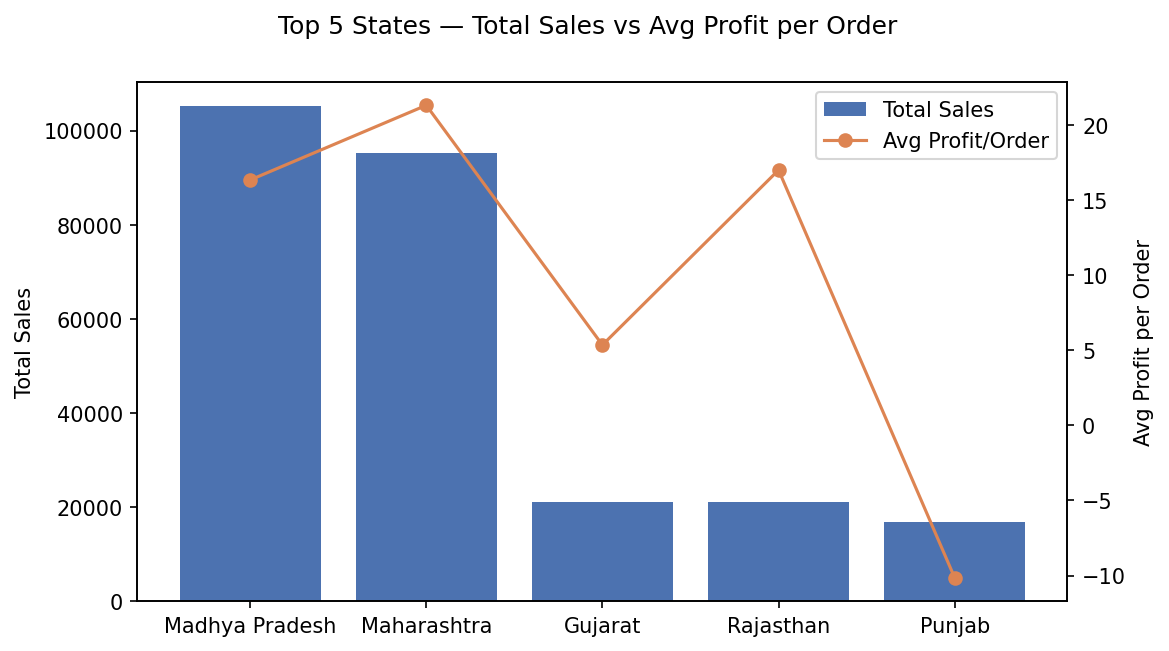

In [ ]:
state_order_count = orders.groupby("State")["Order ID"].count().reset_index(name="Order_Count")
top5_states = state_order_count.sort_values("Order_Count", ascending=False).head(5)["State"].tolist()
print("\nTop 5 states by order count:", top5_states)

state_perf = merged[merged["State"].isin(top5_states)].groupby("State").agg(
    Order_Count=("Order ID", "count"),
    Total_Sales=("Amount", "sum"),
    Avg_Profit=("Profit", "mean"),
).reset_index()
state_perf = state_perf.sort_values("Order_Count", ascending=False)

print("\n=== PART 3: Top 5 States — Sales & Profit ===")
print(state_perf.to_string(index=False))

fig, ax4 = plt.subplots(figsize=(8, 4.5))
x = range(len(state_perf))
ax4.bar(x, state_perf["Total_Sales"], color="#4C72B0", label="Total Sales")
ax4.set_xticks(list(x))
ax4.set_xticklabels(state_perf["State"])
ax4.set_ylabel("Total Sales")
ax5 = ax4.twinx()
ax5.plot(x, state_perf["Avg_Profit"], color="#DD8452", marker="o", label="Avg Profit/Order")
ax5.set_ylabel("Avg Profit per Order")
fig.suptitle("Top 5 States — Total Sales vs Avg Profit per Order")
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax5.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
